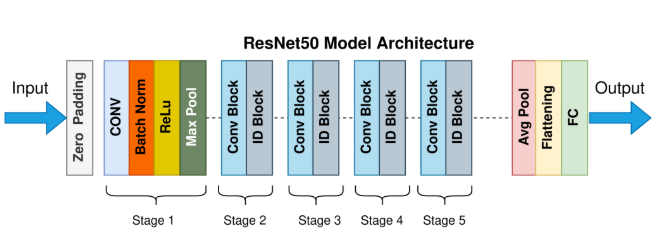

In [74]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import models
from tqdm import tqdm

In [75]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [76]:
transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.5,0.5,0.5), std=(0.5,0.5,0.5))
    ]
)

In [77]:
trainset = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

In [78]:
train_loader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

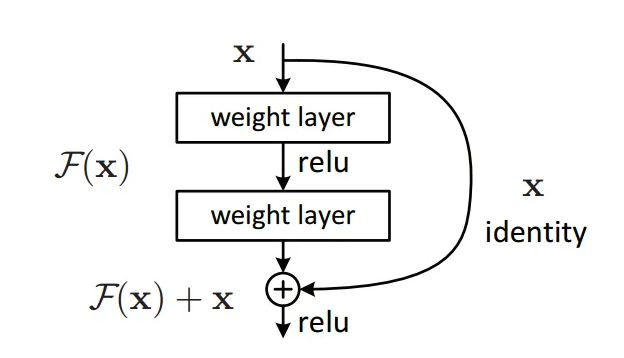

In [79]:
class ResidualBlock(nn.Module):

    def __init__(self, in_channels, out_channels, stride=1, downsample = None):
        """
        cov2d -> batchnorm -> relu -> cov2d -> batchnorm -> downsampling 
        """
        super(ResidualBlock, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.batchNorm1 = nn.BatchNorm2d(num_features=out_channels)
        self.relu = nn.ReLU()

        self.conv2 = nn.Conv2d(in_channels=out_channels, out_channels=out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.batchNorm2 = nn.BatchNorm2d(num_features=out_channels)

        self.downsample = downsample



    def forward(self, x):

        identity = x #self to self connection

        if self.downsample is not None:
            identity = self.downsample(x)
        
        out = self.conv1(x)
        out = self.batchNorm1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.batchNorm2(out)
        out = out + identity # skip connection
        out = self.relu(out)
        
        return out

In [80]:
class CustomResNet(nn.Module):

    def __init__(self, num_classes):
        """
            conv2d -> batchnorm -> relu -> maxpool -> 4 x layer -> avgpool -> fc
        """

        super(CustomResNet,self).__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=7, stride=2, padding=3, bias=False)

        self.bn1 = nn.BatchNorm2d(num_features=64)

        self.relu = nn.ReLU()

        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # 4 x layer
        self.layer1 = self._make_layer(in_channels=64, out_channels=64, blocks=2)
        self.layer2 = self._make_layer(in_channels=64, out_channels=128, blocks=2, stride=2)
        self.layer3 = self._make_layer(in_channels=128, out_channels=256, blocks=2, stride=2)
        self.layer4 = self._make_layer(in_channels=256, out_channels=512, blocks=2, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1,1))
        
        self.fc = nn.Linear(in_features=512, out_features=num_classes)



    def _make_layer(self, in_channels, out_channels, blocks, stride=1):

        downsample = None
        if stride != 1 or in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(num_features=out_channels)
            )

        layers = [ResidualBlock(in_channels=in_channels, out_channels=out_channels, stride=stride, downsample=downsample)]

        for _ in range(1, blocks):
            layers.append(ResidualBlock(in_channels=out_channels, out_channels=out_channels))

        return nn.Sequential(*layers)
    
    def forward(self, x):

        x = self.conv1(x)  # out channel 64
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        # resnet blocks
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x 





In [81]:
use_custom_model = True # use custom model if true 

In [82]:
if use_custom_model:
    model = CustomResNet(10).to(device=device)
else:
    model = models.resnet18(pretrained=True) # basic model
    num_features = model.fc.in_feature
    model.fc = nn.Sequential(
        nn.Linear(num_features, 256),
        nn.ReLU(),
        nn.Linear(256, 10)
    )
    model = model.to(device=device)

In [83]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [85]:
num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    
    
    loop = tqdm(train_loader, total=len(train_loader), leave=True)
    for img, label in loop:
        img, label = img.to(device), label.to(device)
        
        # 1. Gradians to zero
        optimizer.zero_grad()
        
        # 2. Forward pass 
        output = model(img)
        loss = criterion(output, label)
        
        # 3. Backward pass 
        loss.backward()
        
        # 4. Parameter update
        optimizer.step()
        
        running_loss += loss.item()
        
        
        loop.set_description(f"Epoch [{epoch+1}/{num_epochs}]")
        loop.set_postfix(loss=loss.item())

    # average loss
    epoch_loss = running_loss / len(train_loader)
    print(f"-> Epoch {epoch+1} done. Avg Loss: {epoch_loss:.3f}")

Epoch [1/10]: 100%|██████████| 782/782 [00:20<00:00, 37.34it/s, loss=0.793]


-> Epoch 1 done. Avg Loss: 0.698


Epoch [2/10]: 100%|██████████| 782/782 [00:20<00:00, 38.74it/s, loss=0.63] 


-> Epoch 2 done. Avg Loss: 0.592


Epoch [3/10]: 100%|██████████| 782/782 [00:20<00:00, 37.76it/s, loss=2.18] 


...

-> Epoch 8 done. Avg Loss: 0.176


Epoch [9/10]: 100%|██████████| 782/782 [00:20<00:00, 37.73it/s, loss=0.47]  


-> Epoch 9 done. Avg Loss: 0.154


Epoch [10/10]: 100%|██████████| 782/782 [00:20<00:00, 37.47it/s, loss=0.204] 

-> Epoch 10 done. Avg Loss: 0.142


In [86]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for img, label  in test_loader:
        img, label = img.to(device), label.to(device)
        output = model(img)
        _, predicted = torch.max(output, 1)
        total += label.size(0)
        correct += (predicted==label).sum().item()
print(f"Test Accuracy : {100 * correct / total}%")



Test Accuracy : 76.67%
